In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
data = pd.DataFrame({
    'EC': [1980, 1910, 1820, 1890, 1960, 2100, 2430],
    'pH': [5.1, 5.1, 5.2, 5, 4.8, 4.7, 4.8],
    'TDS': [960, 920, 900, 910, 935, 1050, 1280],
    'Temp': [27.5, 26.1, 25, 28.1, 29, 29, 28.6],
    'No. Of. Fruits': [7.86, 16.46, 31.9, 42, 55.6, 64.86, 70.4]
})

In [4]:
X = data[['EC', 'pH', 'TDS', 'Temp']]
y = data[['No. Of. Fruits']]

In [5]:
pca = PCA()
X_reduced = pca.fit_transform(scale(X))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [7]:
X_reduced_train = pca.fit_transform(scale(X_train))
X_reduced_test = pca.transform(scale(X_test))

In [8]:
regr = LinearRegression()
regr.fit(X_reduced_train, y_train)

LinearRegression()

In [9]:
y_pred = regr.predict(X_reduced_test)
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

Mean Squared Error: 108.16366083762597


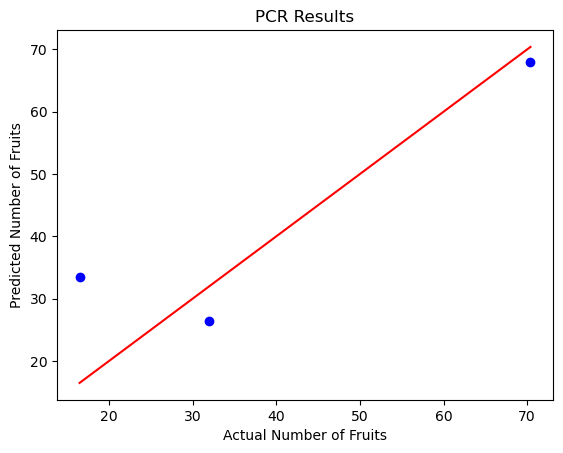

In [10]:
import matplotlib.pyplot as plt

# Plot the actual values
plt.scatter(y_test, y_pred, color='blue')

# Plot the line of perfect fit
min_val = min(y_test['No. Of. Fruits'].min(), y_pred.min())
max_val = max(y_test['No. Of. Fruits'].max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel('Actual Number of Fruits')
plt.ylabel('Predicted Number of Fruits')
plt.title('PCR Results')
plt.show()


In [2]:
pip install factor-analyzer


     ---------------------------------------- 0.0/42.8 kB ? eta -:--:--
     ------------------ ------------------- 20.5/42.8 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 42.8/42.8 kB 417.7 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42621 sha256=e38f14774d34d79ee927651971fc20083017c5db37975518db1f41e1dd346505
  Stored in directory: c:\users\jaszz\appdata\local\pip\cache\wheels\24\59\82\6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor-analy

In [3]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
import pandas as pd

In [5]:
data = pd.DataFrame({
    'EC': [1980, 1910, 1820, 1890, 1960, 2100, 2430],
    'pH': [5.1, 5.1, 5.2, 5, 4.8, 4.7, 4.8],
    'TDS': [960, 920, 900, 910, 935, 1050, 1280],
    'Temp': [27.5, 26.1, 25, 28.1, 29, 29, 28.6],
    'No. Of. Fruits': [7.86, 16.46, 31.9, 42, 55.6, 64.86, 70.4]
})

chi_square_value, p_value = calculate_bartlett_sphericity(data)
print(chi_square_value, p_value)

34.32129546618294 0.000162919804921631


In [6]:
kmo_all, kmo_model = calculate_kmo(data)
print(kmo_model)

0.543666263716838
